In [1]:
# SAFE: clear memory and import modules
import gc, os, psutil
# Do not delete modules; only clear large variables if they exist
for name in list(globals().keys()):
    if name not in ['__name__','__doc__','__package__','__loader__','__spec__','__builtins__']:
        try:
            # keep modules we need
            if name in ('gc','os','psutil'):
                continue
            del globals()[name]
        except Exception:
            pass
gc.collect()
proc = psutil.Process(os.getpid())
print("Memory usage (MB):", round(proc.memory_info().rss/1024**2,2))

Memory usage (MB): 60.98


In [2]:
# Step 1: Load products.csv and convert sales.csv -> partitioned Parquet
import os
import pandas as pd
from tqdm import tqdm  # optional, for progress

# Adjust these paths to where your files are
PRODUCTS_CSV = "products.csv"
SALES_CSV    = "sales.csv"
OUT_DIR      = "data_parquet"  # output folder for parquet parts

os.makedirs(OUT_DIR, exist_ok=True)

# 1) Load products.csv (small)
products = pd.read_csv(PRODUCTS_CSV)
print("Products:", products.shape)
print(products.dtypes)
print(products.head())

# 2) Convert large sales.csv to Parquet in chunks
chunksize = 1_000_000  # reduce to 500_000 if you get memory issues
reader = pd.read_csv(SALES_CSV, parse_dates=["date_"], chunksize=chunksize)

for i, chunk in enumerate(reader):
    # Basic cleanup to avoid obvious junk
    chunk = chunk.dropna(subset=["product_id", "date_", "procured_quantity"])
    # Ensure numeric types
    chunk["procured_quantity"] = pd.to_numeric(chunk["procured_quantity"], errors="coerce").fillna(0).astype(float)
    if "unit_selling_price" in chunk.columns:
        chunk["unit_selling_price"] = pd.to_numeric(chunk["unit_selling_price"], errors="coerce")
    # Write parquet part
    out_path = os.path.join(OUT_DIR, f"part_{i:03d}.parquet")
    chunk.to_parquet(out_path, index=False)
    print(f"Saved {out_path}  rows={len(chunk)}")

print("Done converting sales.csv -> parquet parts in:", OUT_DIR)

# 3) Quick load check (reads all parquet parts as one DataFrame)
sales = pd.read_parquet(OUT_DIR)
print("Sales (parquet) shape:", sales.shape)
print(sales.dtypes)
print(sales.head())

# 4) Optional quick merge check (no writes yet)
merged_sample = sales.merge(products, on="product_id", how="left")
print("Merged sample shape:", merged_sample.shape)
print(merged_sample.head())


Products: (32226, 13)
Unnamed: 0            int64
product_id            int64
product_name         object
unit                 object
product_type         object
brand_name           object
manufacturer_name    object
l0_category          object
l1_category          object
l2_category          object
l0_category_id        int64
l1_category_id        int64
l2_category_id        int64
dtype: object
   Unnamed: 0  product_id                                       product_name  \
0           0      476763                                   Christmas - Card   
1           1      483436  Plum BodyLovin' Hawaiian Rumba Shower Gel - Sa...   
2           2      476825                     Diwali Gift Card Free - Sample   
3           3      483438  Plum BodyLovin' Trippin' Mimosas Shower Gel - ...   
4           4      480473             Flipkart Valentine Day Greeting - Card   

     unit product_type       brand_name  \
0  1 unit         Card              NaN   
1   20 ml       Sample  Plum Body

In [3]:
import pandas as pd
import os
from pathlib import Path

# Paths
PRODUCTS_CSV = "products.csv"
PARQUET_DIR = Path("data_parquet")
CLEANED_DIR = Path("data_cleaned_parts")
FINAL_FILE = Path("sales_cleaned_minimal.parquet")

os.makedirs(CLEANED_DIR, exist_ok=True)

# 1. Load product_id → l1_category mapping
products = pd.read_csv(PRODUCTS_CSV, usecols=["product_id", "l1_category"])
products["l1_category"] = products["l1_category"].fillna("Unknown")

print("Loaded product mapping:", products.shape)

# 2. Iterate parquet parts
parquet_parts = sorted(PARQUET_DIR.glob("part_*.parquet"))
print(f"Found {len(parquet_parts)} parquet parts")

for i, part in enumerate(parquet_parts):
    # Read minimal columns
    sales_chunk = pd.read_parquet(
        part, 
        columns=["date_", "product_id", "procured_quantity", "unit_selling_price"]
    )

    # Merge with category info
    merged = sales_chunk.merge(products, on="product_id", how="left")

    # Keep minimal columns & rename
    merged = merged.rename(columns={
        "date_": "date",
        "procured_quantity": "qty",
        "unit_selling_price": "price"
    })[["date", "l1_category", "qty", "price"]]

    # Clean
    merged["date"] = pd.to_datetime(merged["date"])
    merged["qty"] = pd.to_numeric(merged["qty"], errors="coerce").fillna(0)
    merged["price"] = pd.to_numeric(merged["price"], errors="coerce").fillna(merged["price"].median())
    merged["l1_category"] = merged["l1_category"].fillna("Unknown")

    # Save part
    out_path = CLEANED_DIR / f"cleaned_{i:03d}.parquet"
    merged.to_parquet(out_path, index=False, compression="snappy")

    print(f"Saved {out_path} — rows={len(merged)}")

print("All cleaned parts saved to:", CLEANED_DIR)

# 3. Combine all parts into one final file (fast & memory safe)
dfs = [pd.read_parquet(p) for p in sorted(CLEANED_DIR.glob("cleaned_*.parquet"))]
final_df = pd.concat(dfs, ignore_index=True)
final_df.to_parquet(FINAL_FILE, index=False, compression="snappy")

print("Final cleaned dataset saved:", FINAL_FILE)
print("Shape:", final_df.shape)
print(final_df.head())


Loaded product mapping: (32226, 2)
Found 47 parquet parts
Saved data_cleaned_parts\cleaned_000.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_001.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_002.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_003.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_004.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_005.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_006.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_007.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_008.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_009.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_010.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_011.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_012.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_013.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_014.parquet — rows=1000000
Saved data_cleaned_parts\cleaned_015.parqu

In [4]:
# Step: Aggregate daily total sales per subcategory (l1_category)
import pandas as pd
from pathlib import Path

INPUT_FILE = Path("sales_cleaned_minimal.parquet")
OUTPUT_FILE = Path("daily_category_sales.parquet")

# Load cleaned file (efficient, just 4 cols)
df = pd.read_parquet(INPUT_FILE)

# Aggregate: total qty and avg price per day per category
daily_cat = (
    df.groupby(["l1_category", "date"], as_index=False)
      .agg({
          "qty": "sum",
          "price": "mean"
      })
      .rename(columns={"qty": "total_qty", "price": "avg_price"})
      .sort_values(["l1_category", "date"])
)

# Save aggregated file
daily_cat.to_parquet(OUTPUT_FILE, index=False, compression="snappy")

# Quick info
print("Aggregated dataset saved:", OUTPUT_FILE)
print("Shape:", daily_cat.shape)
print("Unique categories:", daily_cat['l1_category'].nunique())
print("Date range:", daily_cat['date'].min(), "→", daily_cat['date'].max())
print("\nSample:")
print(daily_cat.head(10))


Aggregated dataset saved: daily_category_sales.parquet
Shape: (15581, 4)
Unique categories: 200
Date range: 2022-04-01 00:00:00 → 2022-07-10 00:00:00

Sample:
     l1_category       date  total_qty   avg_price
0  Adult Diapers 2022-04-01       38.0  419.750000
1  Adult Diapers 2022-04-02       31.0  412.280000
2  Adult Diapers 2022-04-03       34.0  408.357143
3  Adult Diapers 2022-04-04       32.0  416.096774
4  Adult Diapers 2022-04-05       45.0  416.142857
5  Adult Diapers 2022-04-06       29.0  411.920000
6  Adult Diapers 2022-04-07       25.0  444.045455
7  Adult Diapers 2022-04-08       26.0  472.086957
8  Adult Diapers 2022-04-09       19.0  485.473684
9  Adult Diapers 2022-04-10       37.0  468.464286


In [ ]:
# Step: Fill missing dates per category (create continuous series)
import pandas as pd
from pathlib import Path

INPUT_FILE = Path("daily_category_sales.parquet")
OUTPUT_FILE = Path("daily_category_filled.parquet")

df = pd.read_parquet(INPUT_FILE)

# Full date range across all categories
full_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")

def fill_dates(group):
    g = group.set_index("date").reindex(full_range)
    g.index.name = "date"
    g["l1_category"] = group["l1_category"].iloc[0]
    g["total_qty"] = g["total_qty"].fillna(0)
    # Forward-fill avg_price; if still NaN, fill with group mean
    g["avg_price"] = g["avg_price"].ffill().bfill().fillna(group["avg_price"].mean())
    return g.reset_index()

filled = df.groupby("l1_category", group_keys=False).apply(fill_dates)

filled.to_parquet(OUTPUT_FILE, index=False, compression="snappy")

print("Continuous daily dataset saved:", OUTPUT_FILE)
print("Shape:", filled.shape)
print("Date range:", filled["date"].min(), "→", filled["date"].max())
print("Example for 1 category:")
print(filled[filled["l1_category"] == filled['l1_category'].iloc[0]].head(10))

Continuous daily dataset saved: daily_category_filled.parquet
Shape: (20200, 4)
Date range: 2022-04-01 00:00:00 → 2022-07-10 00:00:00
Example for 1 category:
        date    l1_category  total_qty   avg_price
0 2022-04-01  Adult Diapers       38.0  419.750000
1 2022-04-02  Adult Diapers       31.0  412.280000
2 2022-04-03  Adult Diapers       34.0  408.357143
3 2022-04-04  Adult Diapers       32.0  416.096774
4 2022-04-05  Adult Diapers       45.0  416.142857
5 2022-04-06  Adult Diapers       29.0  411.920000
6 2022-04-07  Adult Diapers       25.0  444.045455
7 2022-04-08  Adult Diapers       26.0  472.086957
8 2022-04-09  Adult Diapers       19.0  485.473684
9 2022-04-10  Adult Diapers       37.0  468.464286


C:\Users\thunder\AppData\Local\Temp\ipykernel_11168\2257074569.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filled = df.groupby("l1_category", group_keys=False).apply(fill_dates)


In [6]:
import pandas as pd

df = pd.read_parquet("sales_cleaned_minimal.parquet")
print("Raw cleaned data range:", df["date"].min(), "→", df["date"].max())

Raw cleaned data range: 2022-04-01 00:00:00 → 2022-07-10 00:00:00


In [7]:
# Step 5: Create lag, rolling, and time-based features
import pandas as pd
from pathlib import Path

INPUT_FILE = Path("daily_category_filled.parquet")
OUTPUT_FILE = Path("daily_category_features.parquet")

df = pd.read_parquet(INPUT_FILE)

def create_features(g):
    g = g.sort_values("date")
    g["lag_1"] = g["total_qty"].shift(1)
    g["lag_7"] = g["total_qty"].shift(7)
    g["lag_14"] = g["total_qty"].shift(14)
    g["r7_mean"] = g["total_qty"].rolling(7).mean().shift(1)
    g["r14_mean"] = g["total_qty"].rolling(14).mean().shift(1)
    g["r7_std"] = g["total_qty"].rolling(7).std().shift(1)
    g["day_of_week"] = g["date"].dt.dayofweek
    g["month"] = g["date"].dt.month
    return g

feat_df = df.groupby("l1_category", group_keys=False).apply(create_features)

# Drop first rows with NaNs caused by lag/rolling
feat_df = feat_df.dropna().reset_index(drop=True)

feat_df.to_parquet(OUTPUT_FILE, index=False, compression="snappy")

print("Feature-engineered dataset saved:", OUTPUT_FILE)
print("Shape:", feat_df.shape)
print("Columns:", feat_df.columns.tolist())
print(feat_df.head(10))

Feature-engineered dataset saved: daily_category_features.parquet
Shape: (17400, 12)
Columns: ['date', 'l1_category', 'total_qty', 'avg_price', 'lag_1', 'lag_7', 'lag_14', 'r7_mean', 'r14_mean', 'r7_std', 'day_of_week', 'month']
        date    l1_category  total_qty   avg_price  lag_1  lag_7  lag_14  \
0 2022-04-15  Adult Diapers       31.0  461.896552   30.0   26.0    38.0   
1 2022-04-16  Adult Diapers       30.0  480.185185   31.0   19.0    31.0   
2 2022-04-17  Adult Diapers       25.0  478.652174   30.0   37.0    34.0   
3 2022-04-18  Adult Diapers       29.0  468.428571   25.0   38.0    32.0   
4 2022-04-19  Adult Diapers       38.0  463.071429   29.0   21.0    45.0   
5 2022-04-20  Adult Diapers       36.0  464.205882   38.0   28.0    29.0   
6 2022-04-21  Adult Diapers       27.0  475.600000   36.0   30.0    25.0   
7 2022-04-22  Adult Diapers       39.0  485.636364   27.0   31.0    26.0   
8 2022-04-23  Adult Diapers       39.0  472.333333   39.0   30.0    19.0   
9 2022-04-2

C:\Users\thunder\AppData\Local\Temp\ipykernel_11168\2700040716.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feat_df = df.groupby("l1_category", group_keys=False).apply(create_features)


In [8]:
# Step 6: Create train/test sets for 7-day forecast
import pandas as pd
from pathlib import Path

INPUT_FILE = Path("daily_category_features.parquet")
OUTPUT_TRAIN = Path("train_data.parquet")
OUTPUT_TEST = Path("test_data.parquet")

df = pd.read_parquet(INPUT_FILE)

# Forecast horizon
H = 7  # 7 days ahead

# Create target shifted -7 days within each category
df["target"] = df.groupby("l1_category")["total_qty"].shift(-H)

# Drop rows with missing target (end of each series)
df = df.dropna(subset=["target"]).reset_index(drop=True)

# Sort
df = df.sort_values(["l1_category", "date"])

# Define features
features = [
    "lag_1", "lag_7", "lag_14",
    "r7_mean", "r14_mean", "r7_std",
    "avg_price", "day_of_week", "month"
]

# Time-based split: last 10 days as test
split_date = df["date"].max() - pd.Timedelta(days=10)
train = df[df["date"] <= split_date]
test = df[df["date"] > split_date]

# Save
train.to_parquet(OUTPUT_TRAIN, index=False, compression="snappy")
test.to_parquet(OUTPUT_TEST, index=False, compression="snappy")

print("Train/test datasets created")
print(f"Train range: {train['date'].min()} → {train['date'].max()}")
print(f"Test range:  {test['date'].min()} → {test['date'].max()}")
print(f"Train shape: {train.shape},  Test shape: {test.shape}")
print(f"Feature columns ({len(features)}): {features}")


Train/test datasets created
Train range: 2022-04-15 00:00:00 → 2022-06-23 00:00:00
Test range:  2022-06-24 00:00:00 → 2022-07-03 00:00:00
Train shape: (14000, 13),  Test shape: (2000, 13)
Feature columns (9): ['lag_1', 'lag_7', 'lag_14', 'r7_mean', 'r14_mean', 'r7_std', 'avg_price', 'day_of_week', 'month']


Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 3077.94	valid's rmse: 5824.49
[200]	train's rmse: 2729.94	valid's rmse: 5336.01
Early stopping, best iteration is:
[176]	train's rmse: 2801.76	valid's rmse: 5282.23

Evaluation Metrics:
RMSE  : 5,282.232
MAE   : 1,584.469
SMAPE : 71.06%


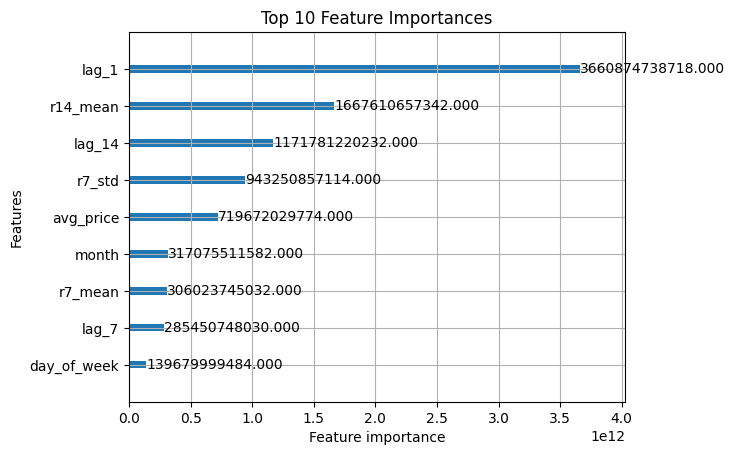

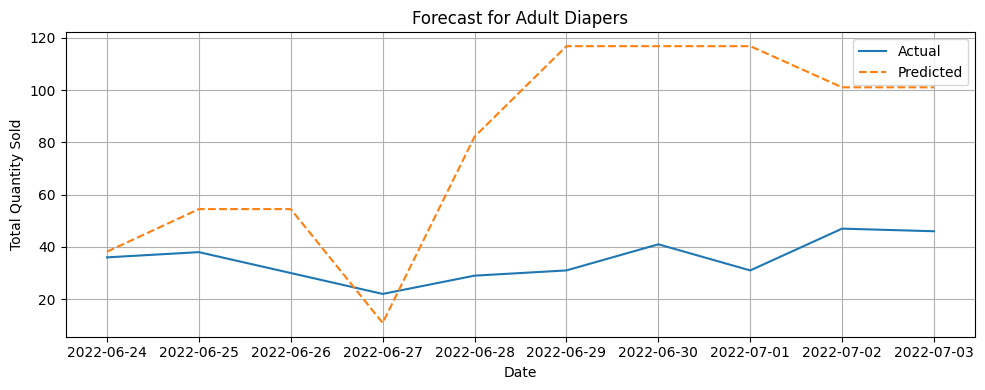

In [ ]:
# Step 7 (Final Version)    : Train LightGBM for 7-day forecast with SMAPE metric
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ========== LOAD DATA ==========
TRAIN_FILE = Path("train_data.parquet")
TEST_FILE  = Path("test_data.parquet")

train = pd.read_parquet(TRAIN_FILE)
test  = pd.read_parquet(TEST_FILE)

features = [
    "lag_1", "lag_7", "lag_14",
    "r7_mean", "r14_mean", "r7_std",
    "avg_price", "day_of_week", "month"
]

X_train, y_train = train[features], train["target"]
X_test,  y_test  = test[features],  test["target"]

# ========== TRAIN MODEL ==========
dtrain = lgb.Dataset(X_train, label=y_train)
dvalid = lgb.Dataset(X_test, label=y_test, reference=dtrain)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "seed": 42,
    "verbosity": -1
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=100)
]

print("Training LightGBM...")
model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dvalid],
    valid_names=["train", "valid"],
    callbacks=callbacks
)

# ========== PREDICTION ==========
preds = model.predict(X_test, num_iteration=model.best_iteration)

# ========== METRICS ==========
rmse = mean_squared_error(y_test, preds, squared=False)
mae  = mean_absolute_error(y_test, preds)

# Safe MAPE alternative: SMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) /
                         (np.abs(y_true) + np.abs(y_pred) + 1e-9))

smape_val = smape(y_test, preds)

print("\nEvaluation Metrics:")
print(f"RMSE  : {rmse:,.3f}")
print(f"MAE   : {mae:,.3f}")
print(f"SMAPE : {smape_val:.2f}%")

# ========== FEATURE IMPORTANCE ==========
lgb.plot_importance(model, importance_type="gain", max_num_features=10)
plt.title("Top 10 Feature Importances")
plt.show()

# ========== SAMPLE FORECAST VISUALIZATION ==========
sample_cat = test["l1_category"].unique()[0]
sample = test[test["l1_category"] == sample_cat].copy()
sample["pred"] = model.predict(sample[features])

plt.figure(figsize=(10, 4))
plt.plot(sample["date"], sample["target"], label="Actual")
plt.plot(sample["date"], sample["pred"], label="Predicted", linestyle="--")
plt.title(f"Forecast for {sample_cat}")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# Step 8: Forecast July 4–July 10 using trained LightGBM model
import pandas as pd
import numpy as np
from pathlib import Path

# Reload base filled dataset (till July 10)
base = pd.read_parquet("daily_category_filled.parquet")

# We’ll forecast 7 days beyond the last available date
last_date = base["date"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=7, freq="D")

# Load trained model & feature list from previous step
import lightgbm as lgb
model = lgb.Booster(model_file="LightGBM_model.txt") if Path("LightGBM_model.txt").exists() else model
features = [
    "lag_1", "lag_7", "lag_14",
    "r7_mean", "r14_mean", "r7_std",
    "avg_price", "day_of_week", "month"
]

# We’ll iteratively build lag/rolling features as we move day by day
forecast_list = []

for step, fdate in enumerate(future_dates, 1):
    future_rows = []
    for cat, hist in base.groupby("l1_category"):
        hist = hist.sort_values("date")
        # Create one-row feature snapshot for this future date
        row = {
            "date": fdate,
            "l1_category": cat,
            "avg_price": hist["avg_price"].iloc[-7:].mean(),  # last week’s avg price
            "lag_1": hist["total_qty"].iloc[-1],
            "lag_7": hist["total_qty"].iloc[-7] if len(hist) >= 7 else hist["total_qty"].iloc[-1],
            "lag_14": hist["total_qty"].iloc[-14] if len(hist) >= 14 else hist["total_qty"].iloc[-1],
            "r7_mean": hist["total_qty"].iloc[-7:].mean(),
            "r14_mean": hist["total_qty"].iloc[-14:].mean() if len(hist) >= 14 else hist["total_qty"].mean(),
            "r7_std": hist["total_qty"].iloc[-7:].std(),
            "day_of_week": fdate.dayofweek,
            "month": fdate.month
        }
        # Predict demand
        row["forecast_qty"] = model.predict(np.array([[
            row["lag_1"], row["lag_7"], row["lag_14"],
            row["r7_mean"], row["r14_mean"], row["r7_std"],
            row["avg_price"], row["day_of_week"], row["month"]
        ]]))[0]
        future_rows.append(row)
    future_df = pd.DataFrame(future_rows)
    forecast_list.append(future_df)
    # Append predictions as new history for iterative forecasting
    base = pd.concat([base, future_df.rename(columns={"forecast_qty": "total_qty"})], ignore_index=True)

# Combine all forecasts
all_forecasts = pd.concat(forecast_list, ignore_index=True)

# Save
all_forecasts.to_parquet("forecast_next7days.parquet", index=False, compression="snappy")
print("Saved 7-day forecasts → forecast_next7days.parquet")
print(all_forecasts.head(10))

Saved 7-day forecasts → forecast_next7days.parquet
        date        l1_category   avg_price    lag_1    lag_7  lag_14  \
0 2022-07-11      Adult Diapers  479.755694     46.0     22.0     0.0   
1 2022-07-11  Antiseptic Liquid  186.248370    406.0    345.0     0.0   
2 2022-07-11         Appliances  820.495260     14.0     16.0     0.0   
3 2022-07-11       Asian Sauces   75.029038    301.0    234.0     0.0   
4 2022-07-11               Atta  266.248987  10433.0  10263.0     0.0   
5 2022-07-11          Baby Food  339.562168   1002.0    849.0     0.0   
6 2022-07-11      Baby Gift Set  592.405952      8.0      4.0     0.0   
7 2022-07-11        Baby Pharma  160.415130     87.0     98.0     0.0   
8 2022-07-11     Baby Skin Care  221.251820    265.0    272.0     0.0   
9 2022-07-11               Bags  551.357143      2.0      1.0     0.0   

       r7_mean     r14_mean      r7_std  day_of_week  month  forecast_qty  
0    35.285714    25.071429    9.464218            0      7     35.54

C:\Users\thunder\AppData\Local\Temp\ipykernel_11168\2208057812.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_hist = hist.groupby("l1_category", group_keys=False).apply(
c:\Users\thunder\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\thunder\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operat

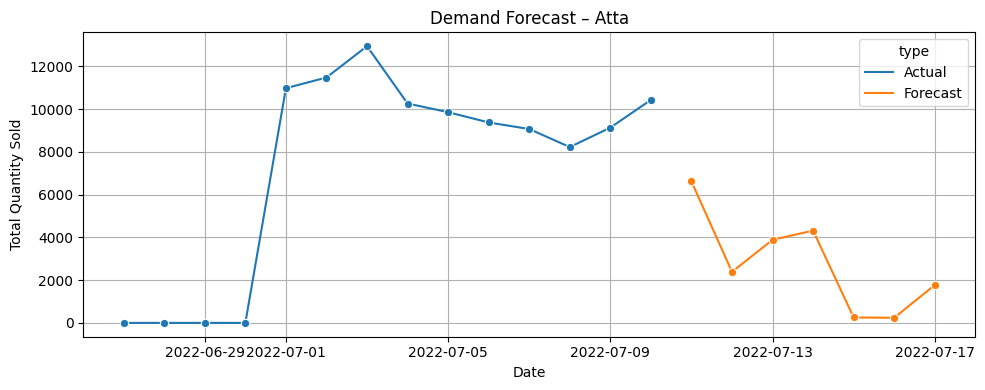

Available categories: ['Adult Diapers' 'Antiseptic Liquid' 'Appliances' 'Asian Sauces' 'Atta'
 'Baby Food' 'Baby Gift Set' 'Baby Pharma' 'Baby Skin Care' 'Bags'
 'Baking Ingredients & Mixes' 'Bath & Beauty Gifts' 'Bath & Hair Care'
 'Bathing Soaps' 'Bathroom Essentials']


In [11]:
# Step 9: Visualization dashboard for category forecasts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FORECAST_FILE = Path("forecast_next7days.parquet")
HIST_FILE     = Path("daily_category_filled.parquet")

forecast = pd.read_parquet(FORECAST_FILE)
hist = pd.read_parquet(HIST_FILE)

# Combine last 14 historical days + 7-day forecast
last_hist = hist.groupby("l1_category", group_keys=False).apply(
    lambda g: g.sort_values("date").tail(14)
)[["date", "l1_category", "total_qty"]]
last_hist = last_hist.rename(columns={"total_qty": "actual_qty"})

forecast["type"] = "Forecast"
last_hist["type"] = "Actual"
last_hist = last_hist.rename(columns={"actual_qty": "forecast_qty"})

combined = pd.concat([last_hist, forecast], ignore_index=True)

# -------- Plot function --------
def plot_category(cat):
    subset = combined[combined["l1_category"] == cat].sort_values("date")
    plt.figure(figsize=(10,4))
    sns.lineplot(x="date", y="forecast_qty", hue="type", data=subset, marker="o")
    plt.title(f"Demand Forecast – {cat}")
    plt.xlabel("Date")
    plt.ylabel("Total Quantity Sold")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------- Usage --------
# Example: visualize one category
plot_category("Atta")

# Or, list top categories available:
print("Available categories:", combined['l1_category'].unique()[:15])
